# 🎓 UJIAN AKHIR SEMESTER — BENGKEL KODING DATA SCIENCE
## Prediksi Churn Pelanggan (Customer Churn Prediction)

**Universitas Dian Nuswantoro — Semester Genap 2025/2026**  
**Masa Pengerjaan:** 18 Mei 2026 – 26 Juni 2026

---

**Identitas:**
- **Nama:** Firnanda Rahmawati
- **NIM:** A11.2023.15373
- **Kelas:** DS-02

---

## 📋 Latar Belakang
Churn adalah kondisi pelanggan berhenti menggunakan layanan. Project ini membangun model prediksi churn menggunakan beberapa kategori model machine learning dan men-deploy model terbaik ke Streamlit Cloud.

## 🎯 Tujuan
1. EDA komprehensif
2. Membangun **9 model** (3 kategori × 3 skenario)
3. **Menangani class imbalance** dengan SMOTE
4. Mengevaluasi & memilih model terbaik
5. Deploy ke Streamlit Cloud

## 📊 Dataset
- **Sumber:** [Sales and Marketing Dataset (Kaggle)](https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset)
- **Sample:** 15.000 records
- **Target:** `churn` (1 = churn, 0 = tidak)

## 🗓️ ROADMAP MINGGUAN

| Minggu | Periode | Fokus |
|--------|---------|-------|
| **Minggu 1** | 18–24 Mei | EDA + analisis imbalance |
| **Minggu 2** | 25–31 Mei | Direct Modeling |
| **Minggu 3** | 01–07 Juni | Preprocessing + **SMOTE** |
| **Minggu 4** | 08–14 Juni | Hyperparameter Tuning + Feature Selection |
| **Minggu 5** | 15–26 Juni | Deployment ke Streamlit Cloud |

---
# 🟢 MINGGU 1 (18 – 24 Mei 2026)
## Setup & Exploratory Data Analysis

**Target:**
1. Setup environment
2. Load dataset
3. 5 baris pertama, info, statistik
4. Analisis missing value + diagram batang
5. Distribusi target + **analisis imbalance**
6. Heatmap korelasi

## 1.1 Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Utility
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Semua library berhasil di-import")

✅ Semua library berhasil di-import


> 📦 **Catatan instalasi:** SMOTE berasal dari library `imbalanced-learn`. Jika belum terinstall:
> ```
> pip install imbalanced-learn
> ```

## 1.2 Load Dataset

In [2]:
df = pd.read_csv('sales_and_marketing.csv')  # sesuaikan nama file dari Kaggle
print(f"Shape: {df.shape}")

Shape: (15000, 30)


## 1.3 5 Baris Pertama

In [3]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


## 1.4 Info Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

## 1.5 Statistik Deskriptif

In [5]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [6]:
df.describe(include='object')

,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


## 1.6 Analisis Missing Value

In [7]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah': df.isnull().sum(),
    'Persentase (%)': missing_pct.round(2)
}).sort_values('Persentase (%)', ascending=False)
print("Kolom dengan missing value:")
print(missing_df[missing_df['Jumlah'] > 0])

Kolom dengan missing value:
                    Jumlah  Persentase (%)
coupon_code           6133           40.89
age                   1200            8.00
total_spent           1050            7.00
gender                 738            4.92
satisfaction_score     702            4.68


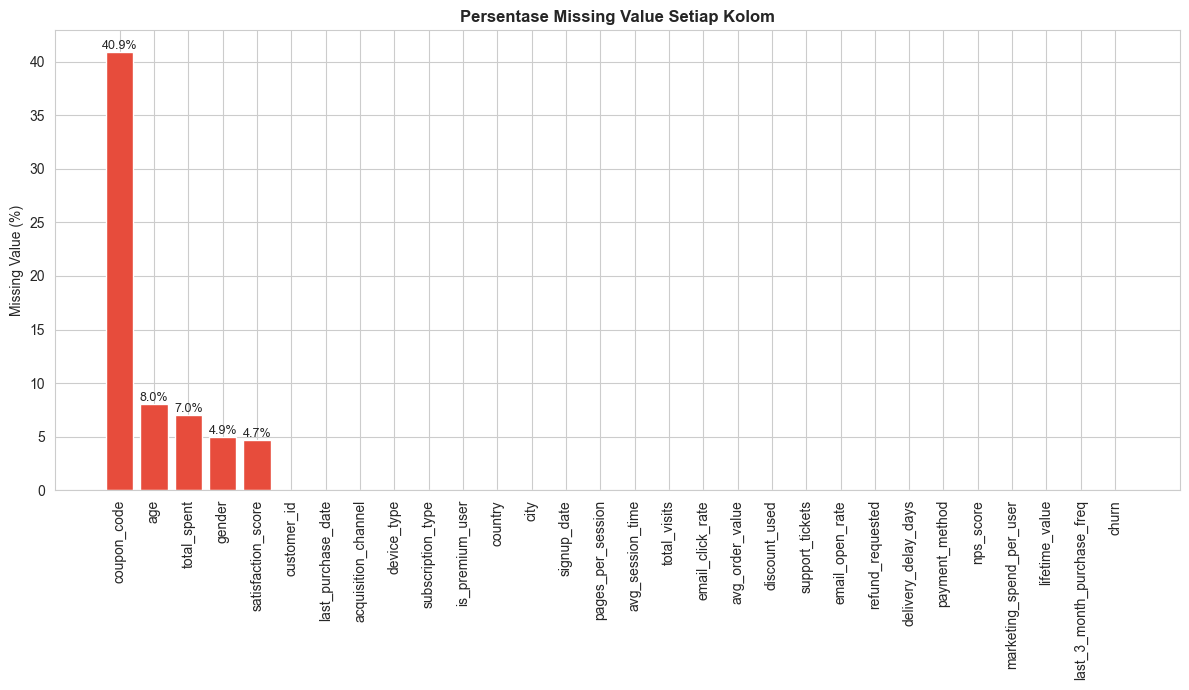

In [8]:
# Visualisasi
plt.figure(figsize=(12, 7))
m = missing_pct.sort_values(ascending=False)
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in m.values]
plt.bar(range(len(m)), m.values, color=colors)
plt.xticks(range(len(m)), m.index, rotation=90)
plt.ylabel('Missing Value (%)')
plt.title('Persentase Missing Value Setiap Kolom', fontweight='bold')
for i, (_, v) in enumerate(m.items()):
    if v > 0:
        plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 1.7 Distribusi Target (Churn)

In [9]:
churn_counts = df['churn'].value_counts()
churn_percent = df['churn'].value_counts(normalize=True) * 100
print(f"Tidak Churn (0): {churn_counts[0]} ({churn_percent[0]:.2f}%)")
print(f"Churn (1)      : {churn_counts[1]} ({churn_percent[1]:.2f}%)")

Tidak Churn (0): 12702 (84.68%)
Churn (1)      : 2298 (15.32%)


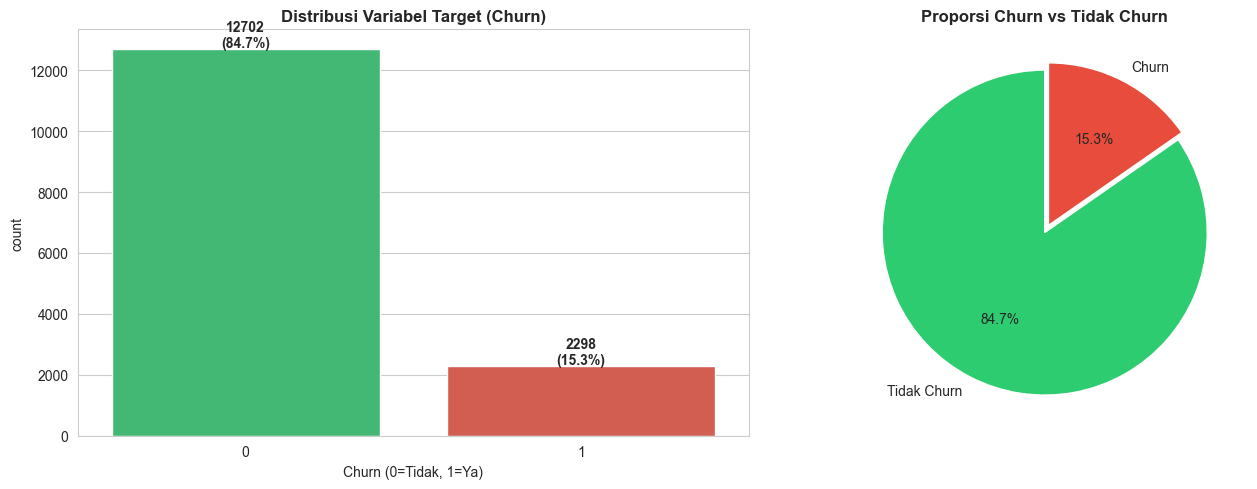

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='churn', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Variabel Target (Churn)', fontweight='bold')
axes[0].set_xlabel('Churn (0=Tidak, 1=Ya)')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v}\n({churn_percent[i]:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Tidak Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporsi Churn vs Tidak Churn', fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Analisis Class Imbalance

Cek apakah dataset **imbalanced** (tidak seimbang antar kelas). Pada masalah churn, kelas minoritas (churn=1) biasanya jauh lebih sedikit.

In [11]:
ratio = churn_counts[0] / churn_counts[1]
minority_pct = churn_percent[1]

print(f"Rasio mayoritas (0) : minoritas (1) = {ratio:.2f} : 1")
print(f"Persentase kelas minoritas (churn=1) = {minority_pct:.2f}%\n")

if minority_pct >= 40:
    status, action = "✅ BALANCED", "Tidak perlu balancing khusus."
elif minority_pct >= 20:
    status, action = "⚠️ MILDLY IMBALANCED", "Stratified split + class_weight='balanced' saat tuning."
elif minority_pct >= 10:
    status, action = "⚠️⚠️ MODERATELY IMBALANCED", "Perlu SMOTE + class_weight='balanced'."
else:
    status, action = "🚨 SEVERELY IMBALANCED", "Wajib SMOTE + class_weight + fokus F1/Recall."

print(f"Status   : {status}")
print(f"Tindakan : {action}\n")
print("📌 IMPLIKASI:")
print("- Accuracy BUKAN metrik utama (menyesatkan pada imbalanced data)")
print("- Precision, Recall, F1-Score, Confusion Matrix lebih relevan")
print("- Recall kelas Churn (1) = paling penting (deteksi pelanggan yang akan churn)")
print("- Akan ditangani di Minggu 3 dengan SMOTE pada training data")

Rasio mayoritas (0) : minoritas (1) = 5.53 : 1
Persentase kelas minoritas (churn=1) = 15.32%

Status   : ⚠️⚠️ MODERATELY IMBALANCED
Tindakan : Perlu SMOTE + class_weight='balanced'.

📌 IMPLIKASI:
- Accuracy BUKAN metrik utama (menyesatkan pada imbalanced data)
- Precision, Recall, F1-Score, Confusion Matrix lebih relevan
- Recall kelas Churn (1) = paling penting (deteksi pelanggan yang akan churn)
- Akan ditangani di Minggu 3 dengan SMOTE pada training data


## 1.8 CEK OULIER

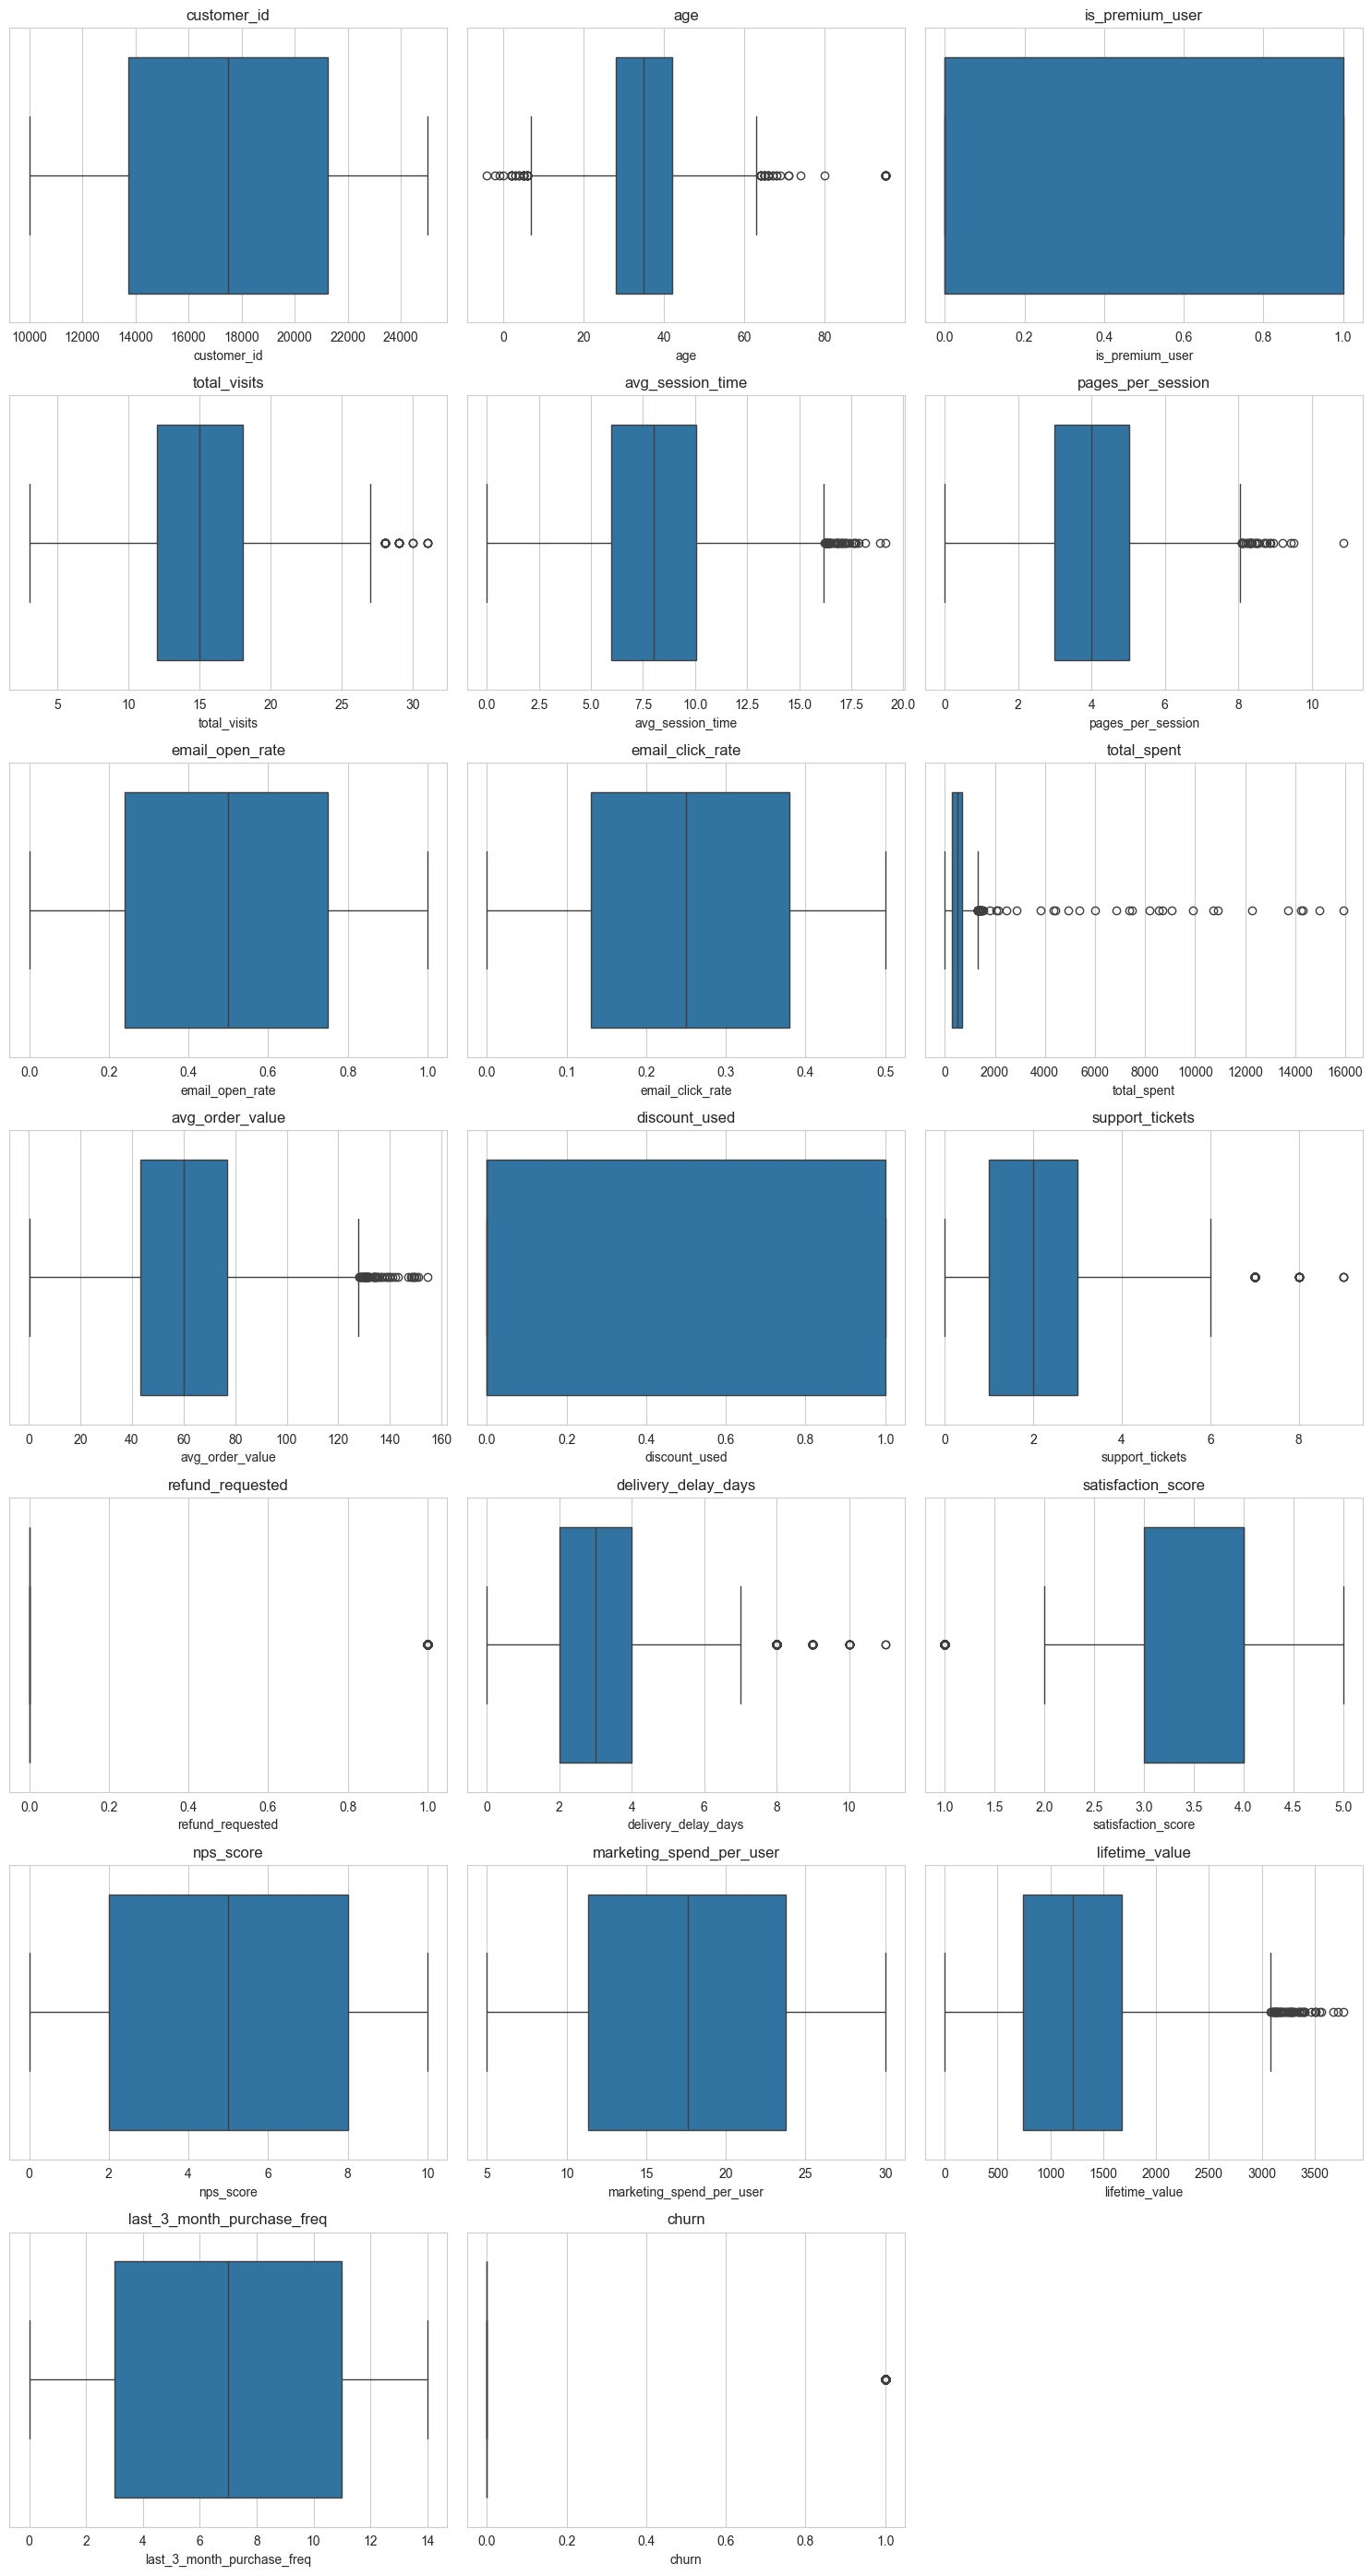

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Hapus subplot yang tidak terpakai
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 1.8 Heatmap Korelasi Fitur Numerik

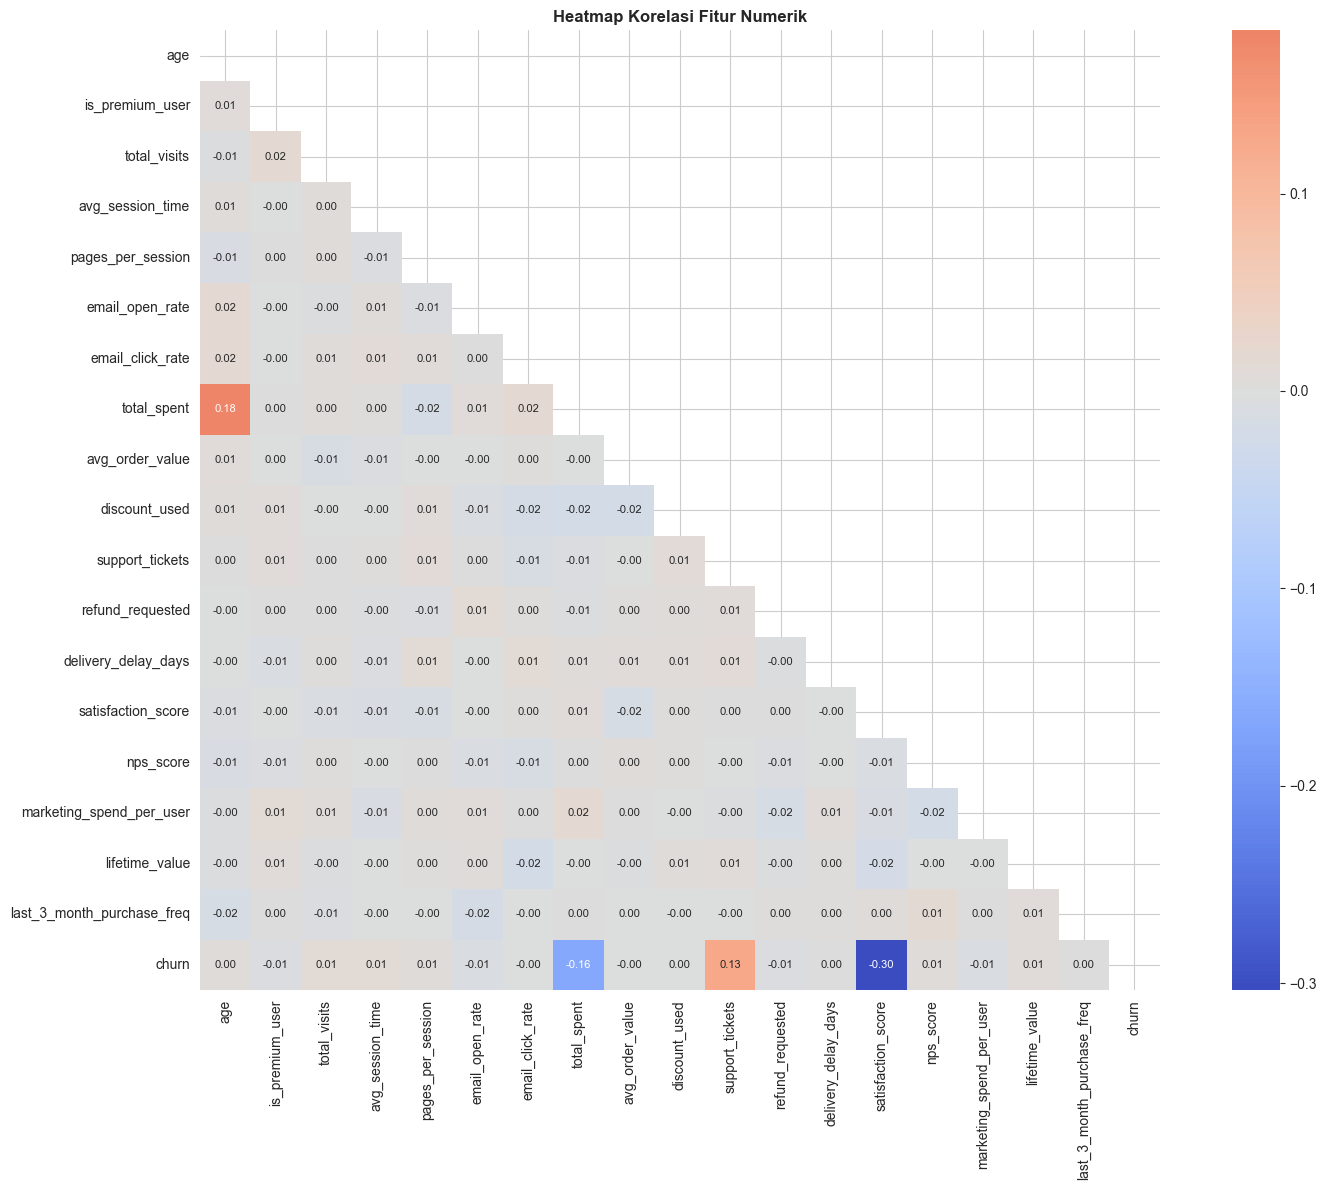

In [13]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
if 'customer_id' in numeric_cols:
    numeric_cols.remove('customer_id')
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, mask=mask, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 fitur paling berkorelasi dengan CHURN:
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250
pages_per_session           0.005871
Name: churn, dtype: float64


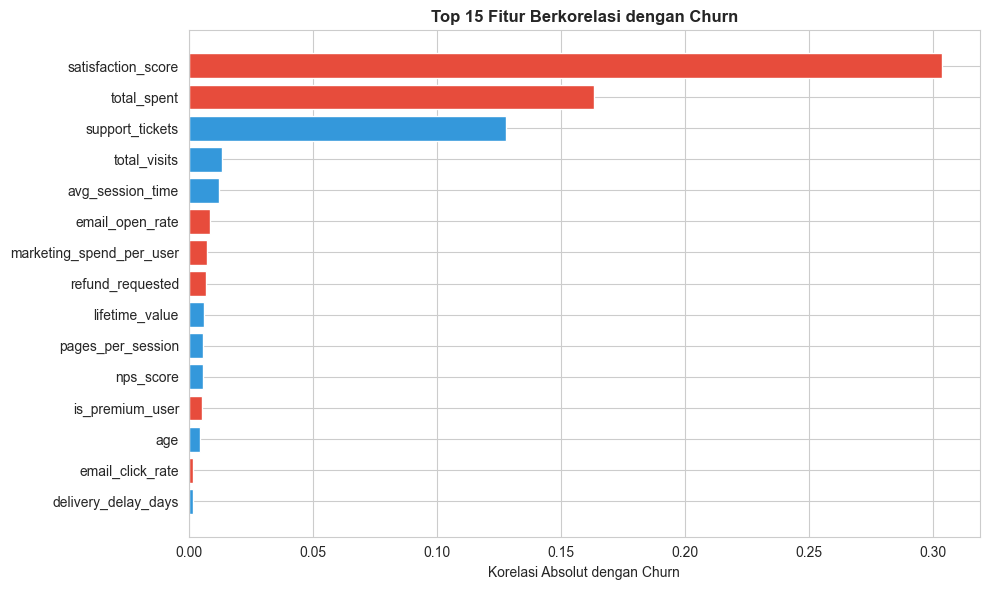

In [14]:
# Top fitur paling berkorelasi dengan churn
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
print("Top 10 fitur paling berkorelasi dengan CHURN:")
print(churn_corr.head(10))

plt.figure(figsize=(10, 6))
top_corr = churn_corr.head(15)
colors = ['#e74c3c' if corr_matrix['churn'][i] < 0 else '#3498db' for i in top_corr.index]
plt.barh(range(len(top_corr)), top_corr.values, color=colors)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Korelasi Absolut dengan Churn')
plt.title('Top 15 Fitur Berkorelasi dengan Churn', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
# 🟡 MINGGU 2 (25 – 31 Mei 2026)
## Direct Modeling (Tanpa Preprocessing & Tuning)

**Target:** Latih 3 model baseline.
- **Konvensional:** Logistic Regression
- **Bagging:** Random Forest
- **Voting:** VotingClassifier (LR + KNN + Decision Tree)

## 2.1 Persiapan Data untuk Direct Modeling

In [15]:
df_direct = df.copy()

# Drop kolom non-numerik & ID untuk baseline (model tidak bisa langsung handle string)
drop_cols_direct = ['customer_id', 'signup_date', 'last_purchase_date',
                    'gender', 'country', 'city', 'acquisition_channel',
                    'device_type', 'subscription_type', 'coupon_code',
                    'payment_method']
drop_cols_direct = [c for c in drop_cols_direct if c in df_direct.columns]
df_direct = df_direct.drop(columns=drop_cols_direct)

# Isi missing dengan median (treatment minimum agar model jalan)
df_direct = df_direct.fillna(df_direct.median(numeric_only=True))

X = df_direct.drop(columns=['churn'])
y = df_direct['churn']
print(f"Shape X: {X.shape}, y: {y.shape}")

Shape X: (15000, 18), y: (15000,)


## 2.2 Train-Test Split (Stratified)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train target: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  target: {y_test.value_counts(normalize=True).round(3).to_dict()}")

X_train: (12000, 18), X_test: (3000, 18)
Train target: {0: 0.847, 1: 0.153}
Test  target: {0: 0.847, 1: 0.153}


## 2.3 Fungsi Evaluasi

In [17]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name=""):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    print(f"\n{'='*55}")
    print(f"📊 {name}")
    print(f"{'='*55}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(classification_report(y_te, y_pred, target_names=['Tidak Churn', 'Churn']))

    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout(); plt.show()

    return {'model_name': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'model': model}

## 2.4 Model #1 — Logistic Regression


📊 Logistic Regression (Direct)
Accuracy : 0.8440
Precision: 0.4692
Recall   : 0.1326
F1-Score : 0.2068
              precision    recall  f1-score   support

 Tidak Churn       0.86      0.97      0.91      2540
       Churn       0.47      0.13      0.21       460

    accuracy                           0.84      3000
   macro avg       0.67      0.55      0.56      3000
weighted avg       0.80      0.84      0.81      3000



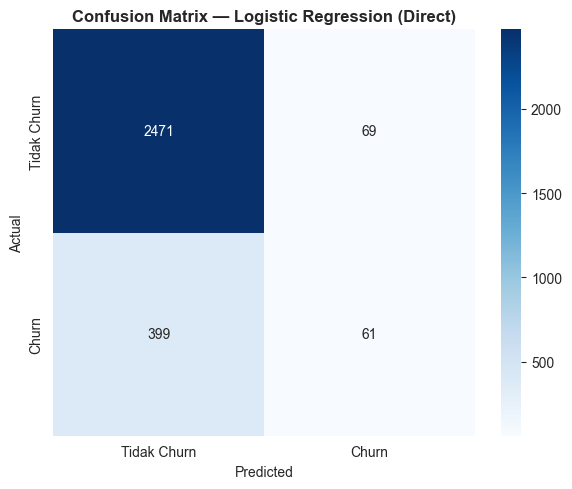

In [18]:
lr_direct = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
result_lr_direct = evaluate_model(lr_direct, X_train, X_test, y_train, y_test,
                                  "Logistic Regression (Direct)")

## 2.5 Model #2 — Random Forest


📊 Random Forest (Direct)
Accuracy : 0.8470
Precision: 0.5015
Recall   : 0.3696
F1-Score : 0.4255
              precision    recall  f1-score   support

 Tidak Churn       0.89      0.93      0.91      2540
       Churn       0.50      0.37      0.43       460

    accuracy                           0.85      3000
   macro avg       0.70      0.65      0.67      3000
weighted avg       0.83      0.85      0.84      3000



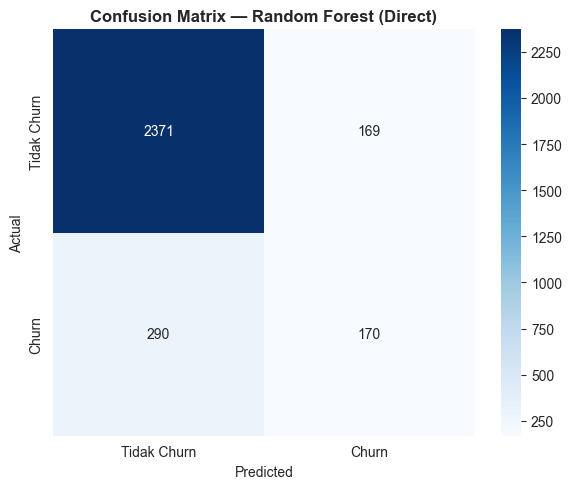

In [19]:
rf_direct = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
result_rf_direct = evaluate_model(rf_direct, X_train, X_test, y_train, y_test,
                                  "Random Forest (Direct)")

## 2.6 Model #3 — Voting Classifier


📊 Voting Classifier (Direct)
Accuracy : 0.8500
Precision: 0.5325
Recall   : 0.1783
F1-Score : 0.2671
              precision    recall  f1-score   support

 Tidak Churn       0.87      0.97      0.92      2540
       Churn       0.53      0.18      0.27       460

    accuracy                           0.85      3000
   macro avg       0.70      0.57      0.59      3000
weighted avg       0.82      0.85      0.82      3000



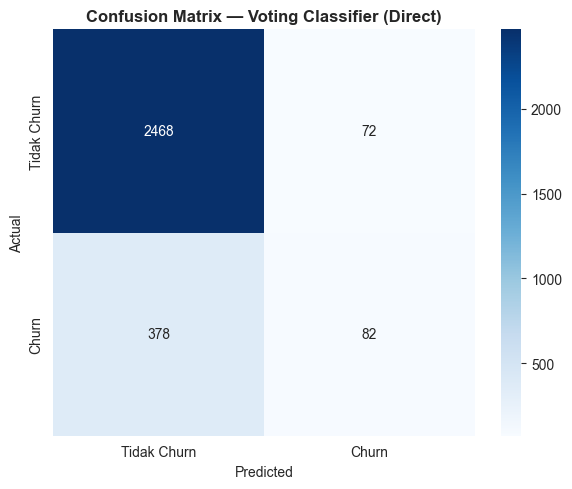

In [20]:
voting_direct = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE))
], voting='hard')
result_voting_direct = evaluate_model(voting_direct, X_train, X_test, y_train, y_test,
                                      "Voting Classifier (Direct)")

## 2.7 Ringkasan Direct Modeling

In [21]:
direct_results = pd.DataFrame([
    {k:v for k,v in result_lr_direct.items() if k!='model'},
    {k:v for k,v in result_rf_direct.items() if k!='model'},
    {k:v for k,v in result_voting_direct.items() if k!='model'}
])
print("RINGKASAN MODEL DIRECT:")
direct_results.style.format({'accuracy':'{:.4f}','precision':'{:.4f}','recall':'{:.4f}','f1':'{:.4f}'})

RINGKASAN MODEL DIRECT:


,model_name,accuracy,precision,recall,f1
0,Logistic Regression (Direct),0.8440,0.4692,0.1326,0.2068
1,Random Forest (Direct),0.8470,0.5015,0.3696,0.4255
2,Voting Classifier (Direct),0.8500,0.5325,0.1783,0.2671


# 🟠 MINGGU 3 — Preprocessing + SMOTE
**Urutan yang benar (anti-leakage):**
1. Drop duplikasi
2. Feature Engineering dari kolom tanggal
3. Drop kolom tidak relevan
4. Encoding kategorikal (get_dummies — aman sebelum split)
5. **Train-Test Split ← GARIS BATAS LEAKAGE**
6. Imputasi missing value (median/mode HANYA dari train)
7. Capping outlier IQR (batas HANYA dari train)
8. Scaling (fit HANYA pada train)
9. SMOTE (HANYA pada training data)
10. Training model

## 3.1 Penanganan Duplikasi

In [22]:
# ============================================================
# STEP 1 — Copy dataset & Drop Duplikasi
# ============================================================
df_pre = df.copy()   # df sudah ada dari Minggu 1
print(f'Shape awal: {df_pre.shape}')

dup_before = df_pre.duplicated().sum()
df_pre = df_pre.drop_duplicates()
print(f'Duplikasi dihapus: {dup_before} baris')
print(f'Shape setelah drop duplikat: {df_pre.shape}')

Shape awal: (15000, 30)
Duplikasi dihapus: 0 baris
Shape setelah drop duplikat: (15000, 30)


## 3.2 Feature Engineering



In [23]:
# ============================================================
# STEP 2 — Feature Engineering dari Kolom Tanggal
# Harus dilakukan SEBELUM drop kolom tanggal
# ============================================================
df_pre['signup_date']        = pd.to_datetime(df_pre['signup_date'], errors='coerce')
df_pre['last_purchase_date'] = pd.to_datetime(df_pre['last_purchase_date'], errors='coerce')

ref_date = df_pre['last_purchase_date'].max()
df_pre['days_since_last_purchase'] = (ref_date - df_pre['last_purchase_date']).dt.days
df_pre['tenure_days']              = (df_pre['last_purchase_date'] - df_pre['signup_date']).dt.days

# ⚠️ Imputasi sementara KHUSUS fitur baru ini — boleh pakai median global
# karena nilainya diturunkan dari tanggal (bukan fitur asli dari data)
df_pre['days_since_last_purchase'] = df_pre['days_since_last_purchase'].fillna(
    df_pre['days_since_last_purchase'].median())
df_pre['tenure_days'] = df_pre['tenure_days'].fillna(df_pre['tenure_days'].median())

print('✅ Feature engineering selesai')
print(df_pre[['days_since_last_purchase', 'tenure_days']].describe())

✅ Feature engineering selesai
       days_since_last_purchase   tenure_days
count              15000.000000  15000.000000
mean                 399.301867    264.791133
std                  231.520502    369.240516
min                    0.000000   -627.000000
25%                  197.000000     -2.000000
50%                  397.000000    266.000000
75%                  602.000000    526.250000
max                  799.000000   1157.000000


## 3.3 Drop Kolom Tidak Relevan

In [24]:
# ============================================================
# STEP 3 — Drop Kolom Tidak Relevan
# Dilakukan SETELAH feature engineering selesai
# ============================================================
drop_cols = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code', 'city']
drop_cols = [c for c in drop_cols if c in df_pre.columns]
df_pre = df_pre.drop(columns=drop_cols)

print(f'Kolom di-drop: {drop_cols}')
print(f'Shape setelah drop: {df_pre.shape}')
print(f'Kolom tersisa: {df_pre.columns.tolist()}')

Kolom di-drop: ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code', 'city']
Shape setelah drop: (15000, 27)
Kolom tersisa: ['gender', 'age', 'country', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn', 'days_since_last_purchase', 'tenure_days']


## 3.4 Encoding Kategorikal

In [25]:
# ============================================================
# STEP 4 — Encoding Kategorikal (get_dummies)
# Boleh sebelum split karena hanya mengubah format kolom,
# tidak menghitung statistik dari data
# ============================================================
cat_cols = df_pre.select_dtypes(include='object').columns.tolist()
print(f'Kolom kategorikal: {cat_cols}')

df_pre_encoded = pd.get_dummies(df_pre, columns=cat_cols, drop_first=True)

# Konversi bool → int (agar tidak error di model)
bool_cols = df_pre_encoded.select_dtypes(include='bool').columns
df_pre_encoded[bool_cols] = df_pre_encoded[bool_cols].astype(int)

print(f'Shape setelah encoding: {df_pre_encoded.shape}')

Kolom kategorikal: ['gender', 'country', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']
Shape setelah encoding: (15000, 38)


## 3.5 Train-Test Split

In [26]:
# ============================================================
# STEP 5 — Train-Test Split
# ⛔ GARIS BATAS LEAKAGE ⛔
# Semua proses yang menghitung statistik (median, mean, IQR, scaler)
# WAJIB dilakukan SETELAH baris ini, menggunakan X_train saja
# ============================================================
X_pre = df_pre_encoded.drop(columns=['churn'])
y_pre = df_pre_encoded['churn']

X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre, y_pre,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_pre
)

print(f'X_train: {X_train_pre.shape} | X_test: {X_test_pre.shape}')
print(f'Distribusi train: {y_train_pre.value_counts(normalize=True).round(3).to_dict()}')
print(f'Distribusi test : {y_test_pre.value_counts(normalize=True).round(3).to_dict()}')

X_train: (12000, 37) | X_test: (3000, 37)
Distribusi train: {0: 0.847, 1: 0.153}
Distribusi test : {0: 0.847, 1: 0.153}


## 3.6 Imputasi Missing Value

In [27]:
# ============================================================
# STEP 6 — Imputasi Missing Value
# ✅ median/mode dihitung HANYA dari X_train_pre
# ✅ Lalu diterapkan ke X_train_pre DAN X_test_pre
# ============================================================
num_cols = X_train_pre.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Hitung median dari training saja
median_dict = {col: X_train_pre[col].median() for col in num_cols}

# Terapkan ke train dan test
for col in num_cols:
    X_train_pre[col] = X_train_pre[col].fillna(median_dict[col])
    X_test_pre[col]  = X_test_pre[col].fillna(median_dict[col])

missing_train = X_train_pre.isnull().sum().sum()
missing_test  = X_test_pre.isnull().sum().sum()
print(f'Missing setelah imputasi → train: {missing_train} | test: {missing_test}')
print('✅ Imputasi selesai (median dari train saja)')

Missing setelah imputasi → train: 0 | test: 0
✅ Imputasi selesai (median dari train saja)


## 3.7 Capping Outlier dengan IQR

In [28]:
# ============================================================
# STEP 7 — Capping Outlier dengan IQR
# ✅ Batas IQR dihitung HANYA dari X_train_pre
# ✅ Clip diterapkan ke train dan test
# ============================================================
iqr_params = {}

for col in num_cols:
    Q1  = X_train_pre[col].quantile(0.25)
    Q3  = X_train_pre[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_params[col] = (lower, upper)        # simpan untuk inferensi nanti

    X_train_pre[col] = X_train_pre[col].clip(lower, upper)
    X_test_pre[col]  = X_test_pre[col].clip(lower, upper)  # pakai batas dari train

print(f'✅ Outlier capping selesai — {len(num_cols)} kolom numerik')

✅ Outlier capping selesai — 37 kolom numerik


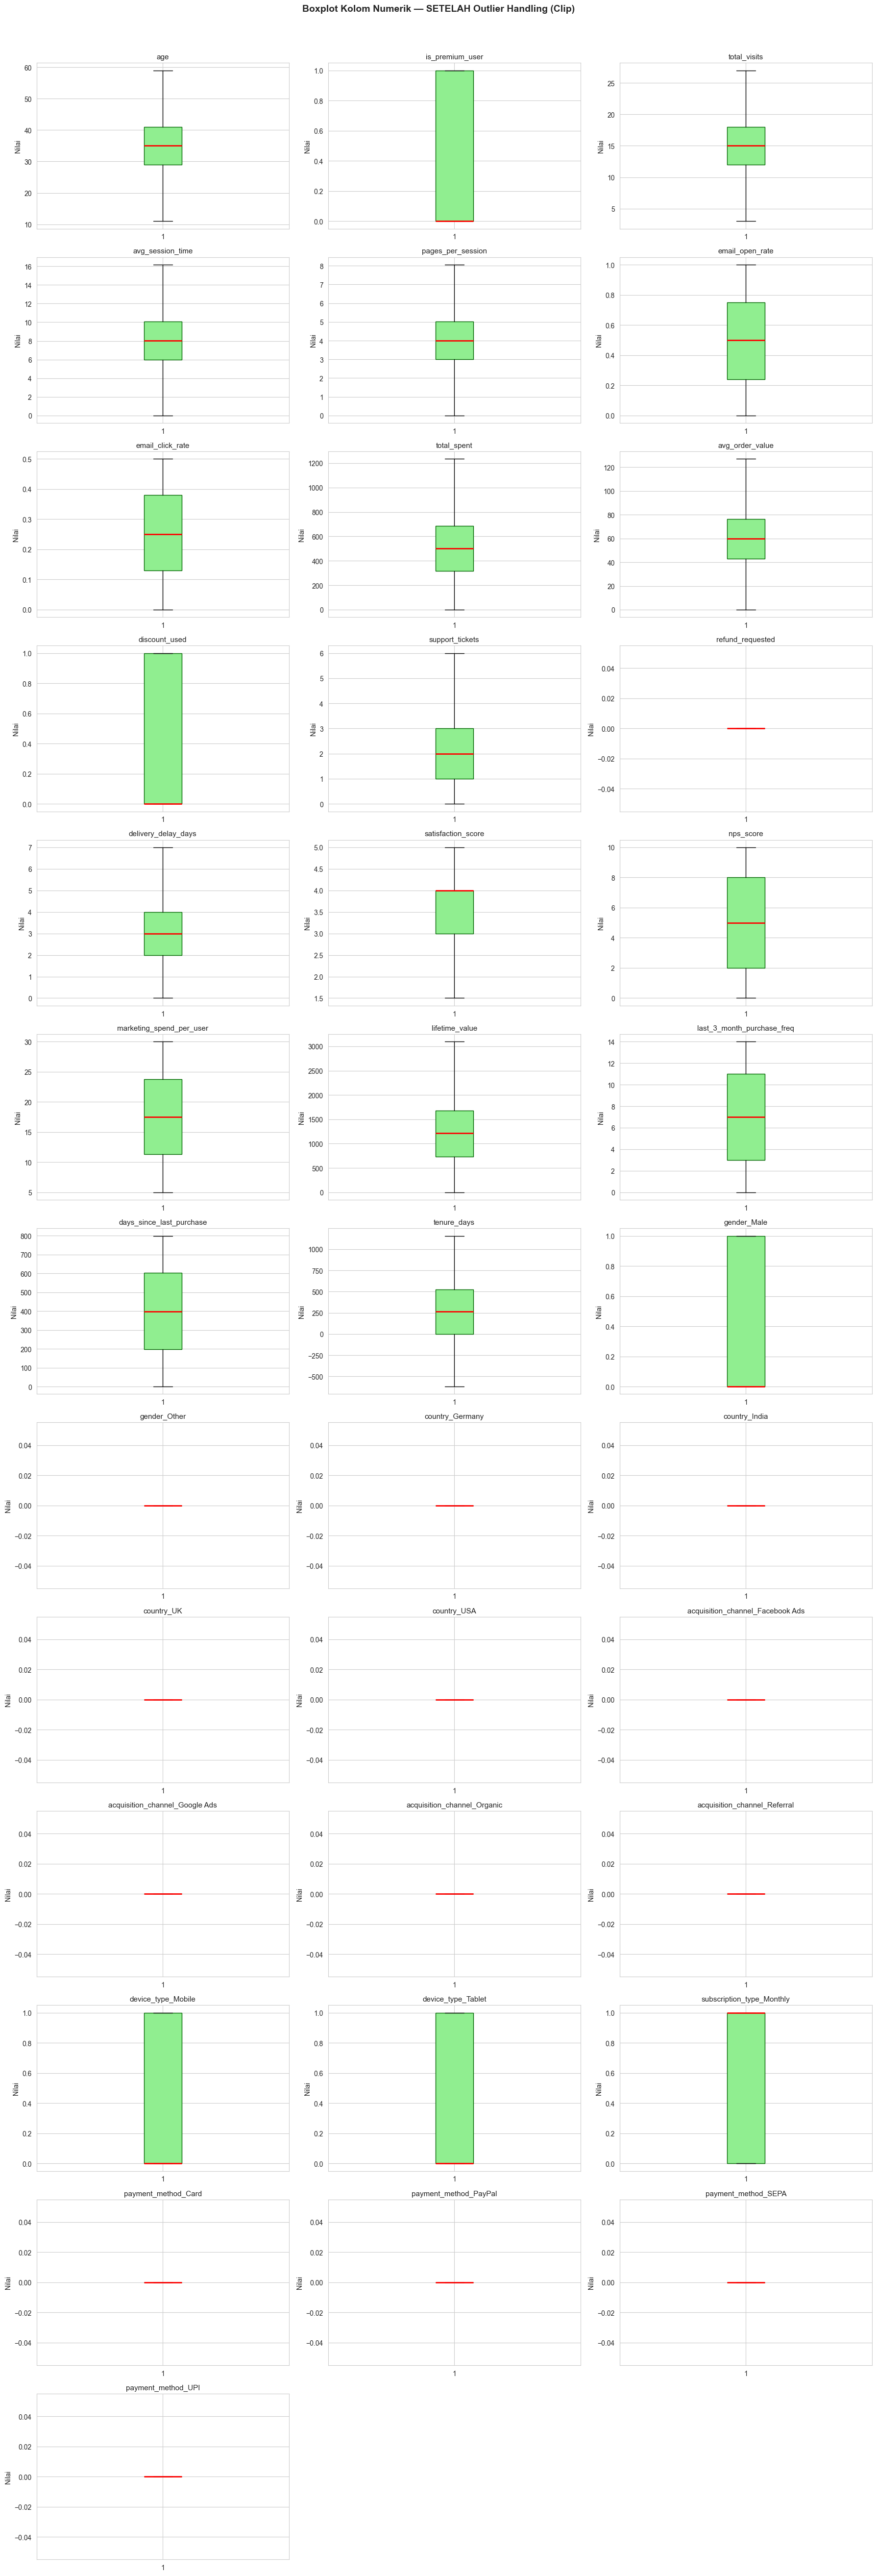

In [29]:
import matplotlib.pyplot as plt

# ============================================================
# Visualisasi Boxplot SETELAH Outlier Handling
# ============================================================

# Pastikan jumlah kolom pembagi sesuai
n_cols = 3
# Menghitung baris secara dinamis berdasarkan panjang num_cols
n_rows = -(-len(num_cols) // n_cols) 

# Membuat figure dan axes untuk subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

# Looping menggunakan num_cols dan X_train_pre
for i, col in enumerate(num_cols):
    # Memanggil data X_train_pre yang sudah berhasil di-clip
    axes[i].boxplot(X_train_pre[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Nilai')

# Menyembunyikan subplot/kanvas ekstra jika jumlah kolom ganjil/tidak pas
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Merapikan dan menampilkan plot
plt.suptitle('Boxplot Kolom Numerik — SETELAH Outlier Handling (Clip)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.8  Scaling (StandardScaler)

In [30]:
# ============================================================
# STEP 8 — Scaling (StandardScaler)
# ✅ fit_transform HANYA pada X_train_pre
# ✅ transform saja pada X_test_pre
# ============================================================
scaler = StandardScaler()

X_train_pre_scaled = scaler.fit_transform(X_train_pre)    # belajar mean & std dari train
X_test_pre_scaled  = scaler.transform(X_test_pre)         # pakai mean & std dari train

# Kembalikan ke DataFrame agar nama kolom tetap ada
X_train_pre_scaled = pd.DataFrame(
    X_train_pre_scaled, columns=X_train_pre.columns, index=X_train_pre.index)
X_test_pre_scaled  = pd.DataFrame(
    X_test_pre_scaled,  columns=X_test_pre.columns,  index=X_test_pre.index)

print('✅ Scaling selesai (fit hanya pada train)')
print(f'X_train_scaled: {X_train_pre_scaled.shape} | X_test_scaled: {X_test_pre_scaled.shape}')

✅ Scaling selesai (fit hanya pada train)
X_train_scaled: (12000, 37) | X_test_scaled: (3000, 37)


## 3.9 SMOTE

In [31]:
print('📊 Distribusi SEBELUM SMOTE:')
print(y_train_pre.value_counts())
print(f'Persentase: {y_train_pre.value_counts(normalize=True).round(3).to_dict()}\n')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pre_scaled, y_train_pre)

print('📊 Distribusi SETELAH SMOTE:')
print(pd.Series(y_train_resampled).value_counts())
print(f'Persentase: {pd.Series(y_train_resampled).value_counts(normalize=True).round(3).to_dict()}\n')
print(f'Training sebelum SMOTE : {len(y_train_pre)}')
print(f'Training sesudah SMOTE : {len(y_train_resampled)}')
print(f'\n✅ SMOTE selesai — test data TIDAK di-SMOTE')

📊 Distribusi SEBELUM SMOTE:
churn
0    10162
1     1838
Name: count, dtype: int64
Persentase: {0: 0.847, 1: 0.153}

📊 Distribusi SETELAH SMOTE:
churn
1    10162
0    10162
Name: count, dtype: int64
Persentase: {1: 0.5, 0: 0.5}

Training sebelum SMOTE : 12000
Training sesudah SMOTE : 20324

✅ SMOTE selesai — test data TIDAK di-SMOTE


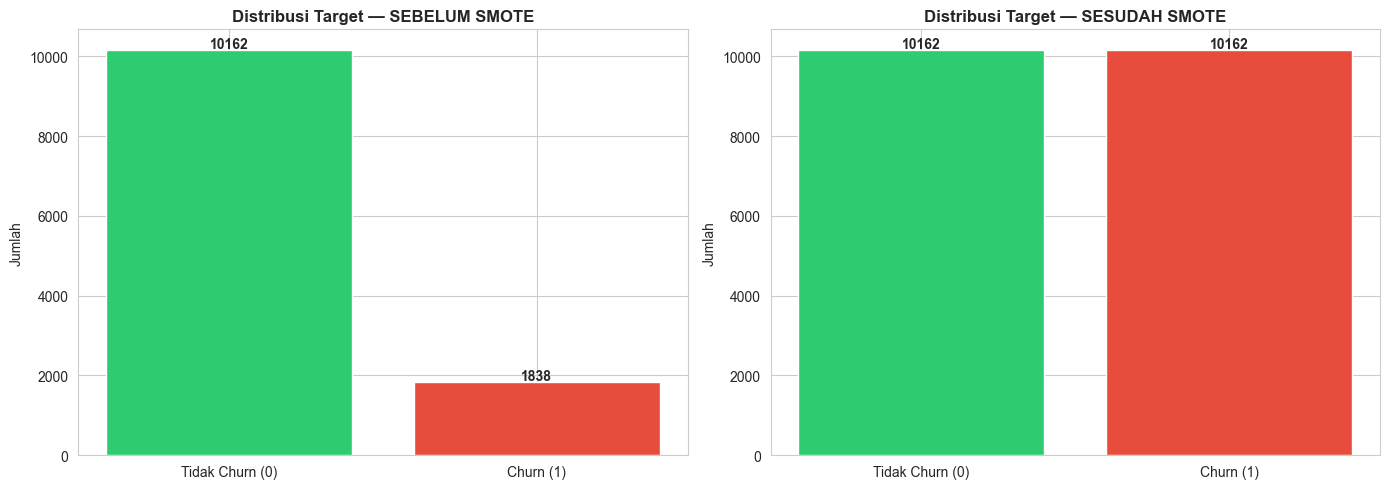

In [32]:
# Visualisasi sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before = y_train_pre.value_counts().sort_index()
axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], before.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Target — SEBELUM SMOTE', fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

after = pd.Series(y_train_resampled).value_counts().sort_index()
axes[1].bar(['Tidak Churn (0)', 'Churn (1)'], after.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribusi Target — SESUDAH SMOTE', fontweight='bold')
axes[1].set_ylabel('Jumlah')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3.10 Training 3 Model dengan Data Hasil SMOTE

In [33]:
# Fungsi evaluasi (sudah ada dari Minggu 2, ditaruh ulang agar cell bisa jalan sendiri)
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name=''):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    print(f"\n{'='*55}")
    print(f'📊 {name}')
    print(f"{'='*55}")
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Tidak Churn', 'Churn']))

    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout(); plt.show()

    return {'model_name': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'model': model}

## 3.10.1 Logistic Regression


📊 Logistic Regression (Preprocessed + SMOTE)
Accuracy : 0.7497
Precision: 0.3470
Recall   : 0.7174
F1-Score : 0.4678
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.76      0.84      2540
       Churn       0.35      0.72      0.47       460

    accuracy                           0.75      3000
   macro avg       0.64      0.74      0.65      3000
weighted avg       0.85      0.75      0.78      3000



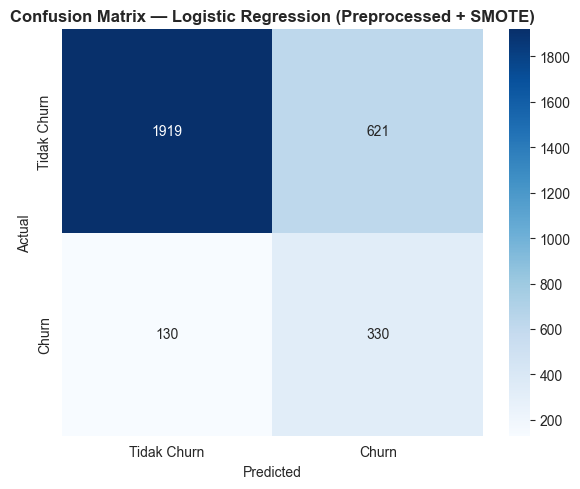

In [34]:
lr_pre = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
result_lr_pre = evaluate_model(
    lr_pre,
    X_train_resampled, X_test_pre_scaled,
    y_train_resampled, y_test_pre,
    'Logistic Regression (Preprocessed + SMOTE)'
)

## 3.10.2 Random Forest


📊 Random Forest (Preprocessed + SMOTE)
Accuracy : 0.8557
Precision: 0.5204
Recall   : 0.7500
F1-Score : 0.6144
              precision    recall  f1-score   support

 Tidak Churn       0.95      0.87      0.91      2540
       Churn       0.52      0.75      0.61       460

    accuracy                           0.86      3000
   macro avg       0.74      0.81      0.76      3000
weighted avg       0.88      0.86      0.87      3000



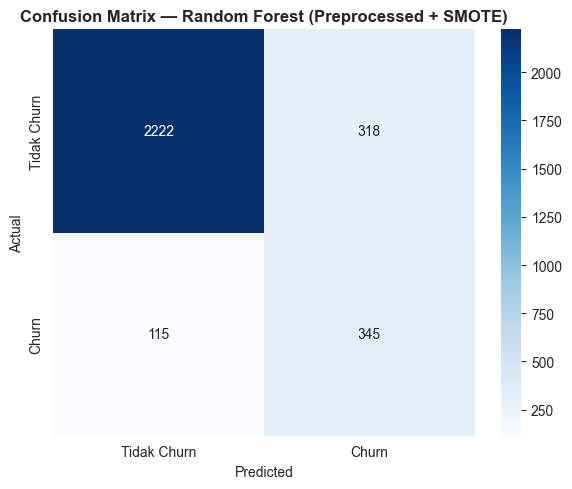

In [35]:
rf_pre = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
result_rf_pre = evaluate_model(
    rf_pre,
    X_train_resampled, X_test_pre_scaled,
    y_train_resampled, y_test_pre,
    'Random Forest (Preprocessed + SMOTE)'
)

## 3.10.3 Voting Classifier


📊 Voting Classifier (Preprocessed + SMOTE)
Accuracy : 0.8010
Precision: 0.4109
Recall   : 0.6870
F1-Score : 0.5142
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.82      0.87      2540
       Churn       0.41      0.69      0.51       460

    accuracy                           0.80      3000
   macro avg       0.67      0.75      0.69      3000
weighted avg       0.86      0.80      0.82      3000



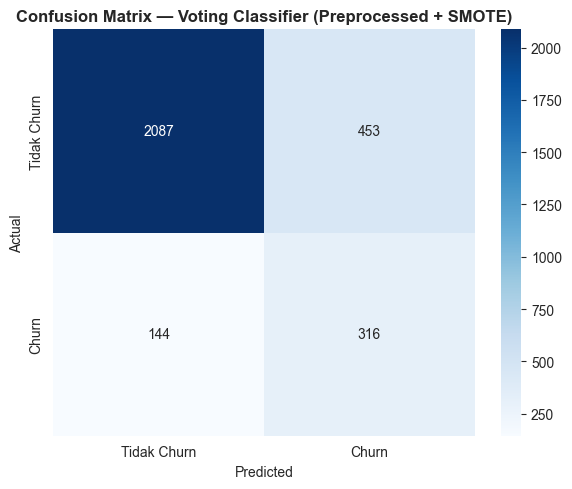

In [36]:
voting_pre = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt',  DecisionTreeClassifier(random_state=RANDOM_STATE))
], voting='hard')
result_voting_pre = evaluate_model(
    voting_pre,
    X_train_resampled, X_test_pre_scaled,
    y_train_resampled, y_test_pre,
    'Voting Classifier (Preprocessed + SMOTE)'
)

## 3.11 Ringkasan

In [37]:
pre_results = pd.DataFrame([
    {k: v for k, v in result_lr_pre.items()     if k != 'model'},
    {k: v for k, v in result_rf_pre.items()     if k != 'model'},
    {k: v for k, v in result_voting_pre.items() if k != 'model'},
])
print('RINGKASAN MODEL DENGAN PREPROCESSING + SMOTE:')
pre_results.style.format({
    'accuracy': '{:.4f}', 'precision': '{:.4f}',
    'recall':   '{:.4f}', 'f1':        '{:.4f}'
})

RINGKASAN MODEL DENGAN PREPROCESSING + SMOTE:


,model_name,accuracy,precision,recall,f1
0,Logistic Regression (Preprocessed + SMOTE),0.7497,0.3470,0.7174,0.4678
1,Random Forest (Preprocessed + SMOTE),0.8557,0.5204,0.7500,0.6144
2,Voting Classifier (Preprocessed + SMOTE),0.8010,0.4109,0.6870,0.5142


---
# 🔵 MINGGU 4 (08 – 14 Juni 2026)
## Hyperparameter Tuning + Feature Selection

**Target:**
1. Feature importance
2. Tuning dengan GridSearchCV / RandomizedSearchCV
3. Gunakan `class_weight='balanced'` sebagai tambahan handling imbalance
4. Best estimator + retrain + evaluasi

## 4.1 Feature Importance

In [38]:
rf_for_imp = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_for_imp.fit(X_train_resampled, y_train_resampled)

feat_imp = pd.DataFrame({
    'feature': X_train_resampled.columns,
    'importance': rf_for_imp.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Feature Importance:")
print(feat_imp.head(15))

Top 15 Feature Importance:
                       feature  importance
13          satisfaction_score    0.291744
7                  total_spent    0.224269
10             support_tickets    0.107180
12         delivery_delay_days    0.035065
14                   nps_score    0.028998
2                 total_visits    0.026355
17  last_3_month_purchase_freq    0.025083
15    marketing_spend_per_user    0.023981
6             email_click_rate    0.023612
18    days_since_last_purchase    0.022024
5              email_open_rate    0.022023
4            pages_per_session    0.021409
3             avg_session_time    0.021368
0                          age    0.020902
16              lifetime_value    0.020854


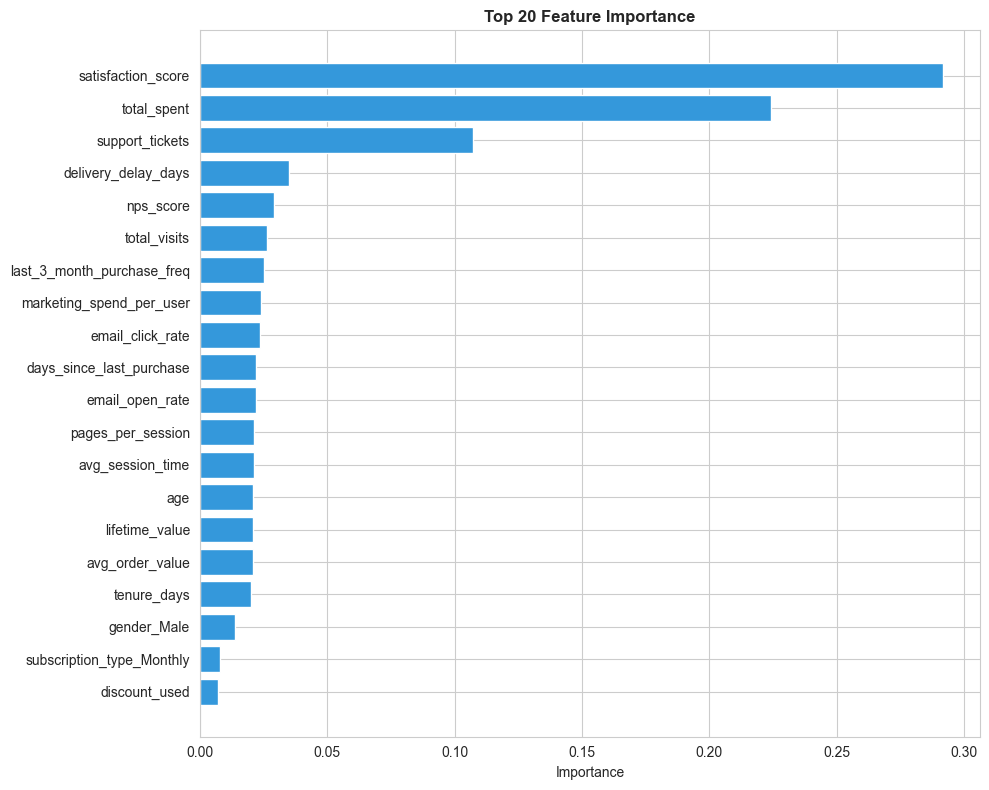

In [39]:
plt.figure(figsize=(10, 8))
top = feat_imp.head(20)
plt.barh(range(len(top)), top['importance'].values, color='#3498db')
plt.yticks(range(len(top)), top['feature'].values)
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [40]:
# Feature selection: ambil fitur kumulatif importance <= 95%
feat_imp['cumulative'] = feat_imp['importance'].cumsum()
selected_features = feat_imp[feat_imp['cumulative'] <= 0.95]['feature'].tolist()
if len(selected_features) < 10:
    selected_features = feat_imp.head(15)['feature'].tolist()

print(f"Jumlah fitur terpilih: {len(selected_features)}")
X_train_sel = X_train_resampled[selected_features]
X_test_sel  = X_test_pre_scaled[selected_features]

Jumlah fitur terpilih: 16


## 4.2 Tuning Logistic Regression
> 💡 Note: parameter `class_weight` ditambahkan untuk extra handling imbalance.

Fitting 5 folds for each of 20 candidates, totalling 100 fits

🏆 Best Params LR: {'C': 0.01, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
🏆 Best CV F1   : 0.7776

📊 Logistic Regression (Tuned)
Accuracy : 0.7507
Precision: 0.3500
Recall   : 0.7304
F1-Score : 0.4732
              precision    recall  f1-score   support

 Tidak Churn       0.94      0.75      0.84      2540
       Churn       0.35      0.73      0.47       460

    accuracy                           0.75      3000
   macro avg       0.64      0.74      0.65      3000
weighted avg       0.85      0.75      0.78      3000



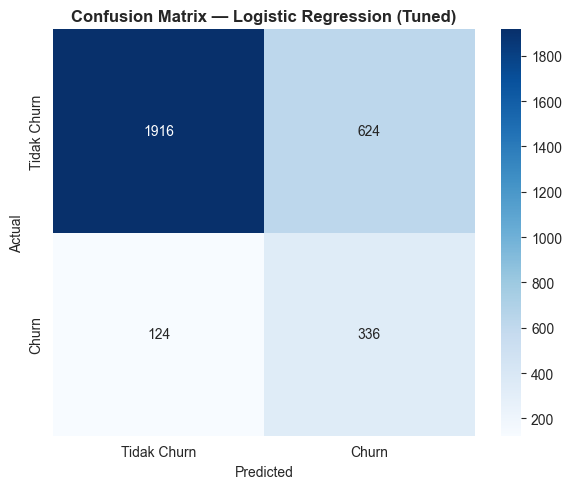

In [41]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}
grid_lr = GridSearchCV(LogisticRegression(random_state=RANDOM_STATE),
                      param_grid_lr, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_lr.fit(X_train_sel, y_train_resampled)
print(f"\n🏆 Best Params LR: {grid_lr.best_params_}")
print(f"🏆 Best CV F1   : {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
result_lr_tuned = evaluate_model(best_lr, X_train_sel, X_test_sel,
                                 y_train_resampled, y_test_pre,
                                 "Logistic Regression (Tuned)")

## 4.3 Tuning Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits

🏆 Best Params RF: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
🏆 Best CV F1   : 0.9060

📊 Random Forest (Tuned)
Accuracy : 0.8560
Precision: 0.5162
Recall   : 0.9696
F1-Score : 0.6737
              precision    recall  f1-score   support

 Tidak Churn       0.99      0.84      0.91      2540
       Churn       0.52      0.97      0.67       460

    accuracy                           0.86      3000
   macro avg       0.75      0.90      0.79      3000
weighted avg       0.92      0.86      0.87      3000



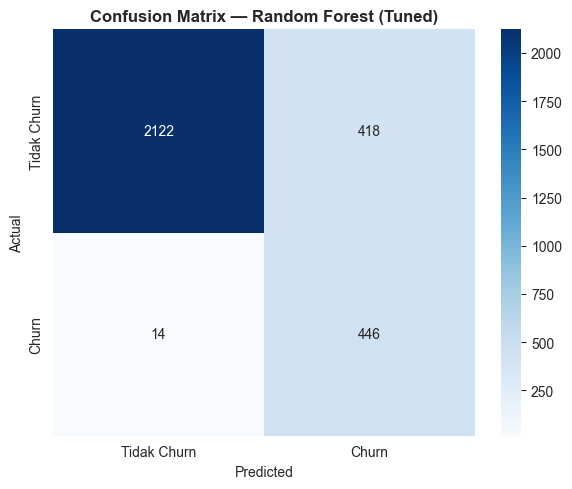

In [42]:
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}
rand_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf, n_iter=20, cv=5, scoring='f1',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
rand_rf.fit(X_train_sel, y_train_resampled)
print(f"\n🏆 Best Params RF: {rand_rf.best_params_}")
print(f"🏆 Best CV F1   : {rand_rf.best_score_:.4f}")

best_rf = rand_rf.best_estimator_
result_rf_tuned = evaluate_model(best_rf, X_train_sel, X_test_sel,
                                 y_train_resampled, y_test_pre,
                                 "Random Forest (Tuned)")

## 4.4 Tuning Voting Classifier

Fitting 5 folds for each of 36 candidates, totalling 180 fits

🏆 Best Params Voting: {'dt__max_depth': 10, 'knn__n_neighbors': 3, 'lr__C': 10}
🏆 Best CV F1        : 0.9168

📊 Voting Classifier (Tuned)
Accuracy : 0.8347
Precision: 0.4767
Recall   : 0.8022
F1-Score : 0.5981
              precision    recall  f1-score   support

 Tidak Churn       0.96      0.84      0.90      2540
       Churn       0.48      0.80      0.60       460

    accuracy                           0.83      3000
   macro avg       0.72      0.82      0.75      3000
weighted avg       0.89      0.83      0.85      3000



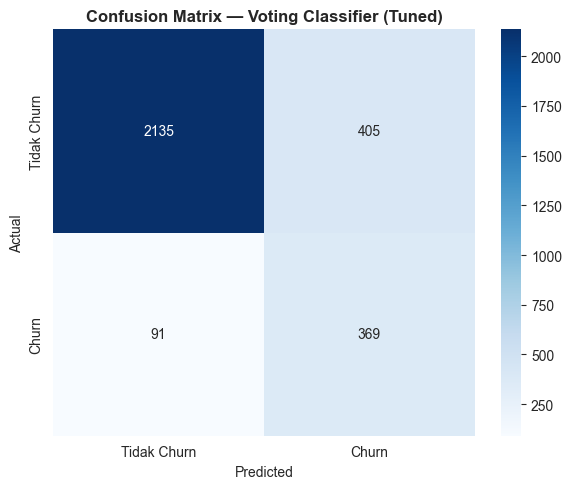

In [43]:
param_grid_voting = {
    'lr__C': [0.1, 1, 10],
    'knn__n_neighbors': [3, 5, 7, 9],
    'dt__max_depth': [None, 10, 20]
}
voting_for_tune = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
], voting='soft')

grid_voting = GridSearchCV(voting_for_tune, param_grid_voting,
                           cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_voting.fit(X_train_sel, y_train_resampled)
print(f"\n🏆 Best Params Voting: {grid_voting.best_params_}")
print(f"🏆 Best CV F1        : {grid_voting.best_score_:.4f}")

best_voting = grid_voting.best_estimator_
result_voting_tuned = evaluate_model(best_voting, X_train_sel, X_test_sel,
                                     y_train_resampled, y_test_pre,
                                     "Voting Classifier (Tuned)")

## 4.5 Ringkasan Model Tuned

In [44]:
tuned_results = pd.DataFrame([
    {k:v for k,v in result_lr_tuned.items() if k!='model'},
    {k:v for k,v in result_rf_tuned.items() if k!='model'},
    {k:v for k,v in result_voting_tuned.items() if k!='model'}
])
print("RINGKASAN MODEL TUNED:")
tuned_results.style.format({'accuracy':'{:.4f}','precision':'{:.4f}','recall':'{:.4f}','f1':'{:.4f}'})

RINGKASAN MODEL TUNED:


,model_name,accuracy,precision,recall,f1
0,Logistic Regression (Tuned),0.7507,0.3500,0.7304,0.4732
1,Random Forest (Tuned),0.8560,0.5162,0.9696,0.6737
2,Voting Classifier (Tuned),0.8347,0.4767,0.8022,0.5981


### ✅ Checklist Minggu 4
- [x] Feature importance + selection
- [x] Tuning LR (GridSearchCV)
- [x] Tuning RF (RandomizedSearchCV)
- [x] Tuning Voting (GridSearchCV)
- [x] `class_weight='balanced'` ditambahkan ke search space
- [ ] **Upload ke GitHub** dengan commit: `"Minggu 4 - Tuning + Feature Selection"`

---
# 🔴 MINGGU 5 (15 – 26 Juni 2026)
## Perbandingan Final & Deployment ke Streamlit Cloud

## 5.1 Perbandingan 9 Model

In [45]:
all_results = pd.DataFrame([
    {**{k:v for k,v in result_lr_direct.items() if k!='model'},     'scenario':'Direct'},
    {**{k:v for k,v in result_rf_direct.items() if k!='model'},     'scenario':'Direct'},
    {**{k:v for k,v in result_voting_direct.items() if k!='model'}, 'scenario':'Direct'},
    {**{k:v for k,v in result_lr_pre.items() if k!='model'},        'scenario':'Preprocessed+SMOTE'},
    {**{k:v for k,v in result_rf_pre.items() if k!='model'},        'scenario':'Preprocessed+SMOTE'},
    {**{k:v for k,v in result_voting_pre.items() if k!='model'},    'scenario':'Preprocessed+SMOTE'},
    {**{k:v for k,v in result_lr_tuned.items() if k!='model'},      'scenario':'Tuned'},
    {**{k:v for k,v in result_rf_tuned.items() if k!='model'},      'scenario':'Tuned'},
    {**{k:v for k,v in result_voting_tuned.items() if k!='model'},  'scenario':'Tuned'},
])
print("="*70)
print("📊 RINGKASAN 9 MODEL")
print("="*70)
print(all_results.to_string(index=False))

best_idx = all_results['f1'].idxmax()
best_row = all_results.iloc[best_idx]
print(f"\n🏆 MODEL TERBAIK: {best_row['model_name']}")
print(f"   F1-Score : {best_row['f1']:.4f}")
print(f"   Accuracy : {best_row['accuracy']:.4f}")
print(f"   Precision: {best_row['precision']:.4f}")
print(f"   Recall   : {best_row['recall']:.4f}")

📊 RINGKASAN 9 MODEL
                                model_name  accuracy  precision   recall       f1           scenario
              Logistic Regression (Direct)  0.844000   0.469231 0.132609 0.206780             Direct
                    Random Forest (Direct)  0.847000   0.501475 0.369565 0.425532             Direct
                Voting Classifier (Direct)  0.850000   0.532468 0.178261 0.267101             Direct
Logistic Regression (Preprocessed + SMOTE)  0.749667   0.347003 0.717391 0.467753 Preprocessed+SMOTE
      Random Forest (Preprocessed + SMOTE)  0.855667   0.520362 0.750000 0.614426 Preprocessed+SMOTE
  Voting Classifier (Preprocessed + SMOTE)  0.801000   0.410923 0.686957 0.514239 Preprocessed+SMOTE
               Logistic Regression (Tuned)  0.750667   0.350000 0.730435 0.473239              Tuned
                     Random Forest (Tuned)  0.856000   0.516204 0.969565 0.673716              Tuned
                 Voting Classifier (Tuned)  0.834667   0.476744 0.80217

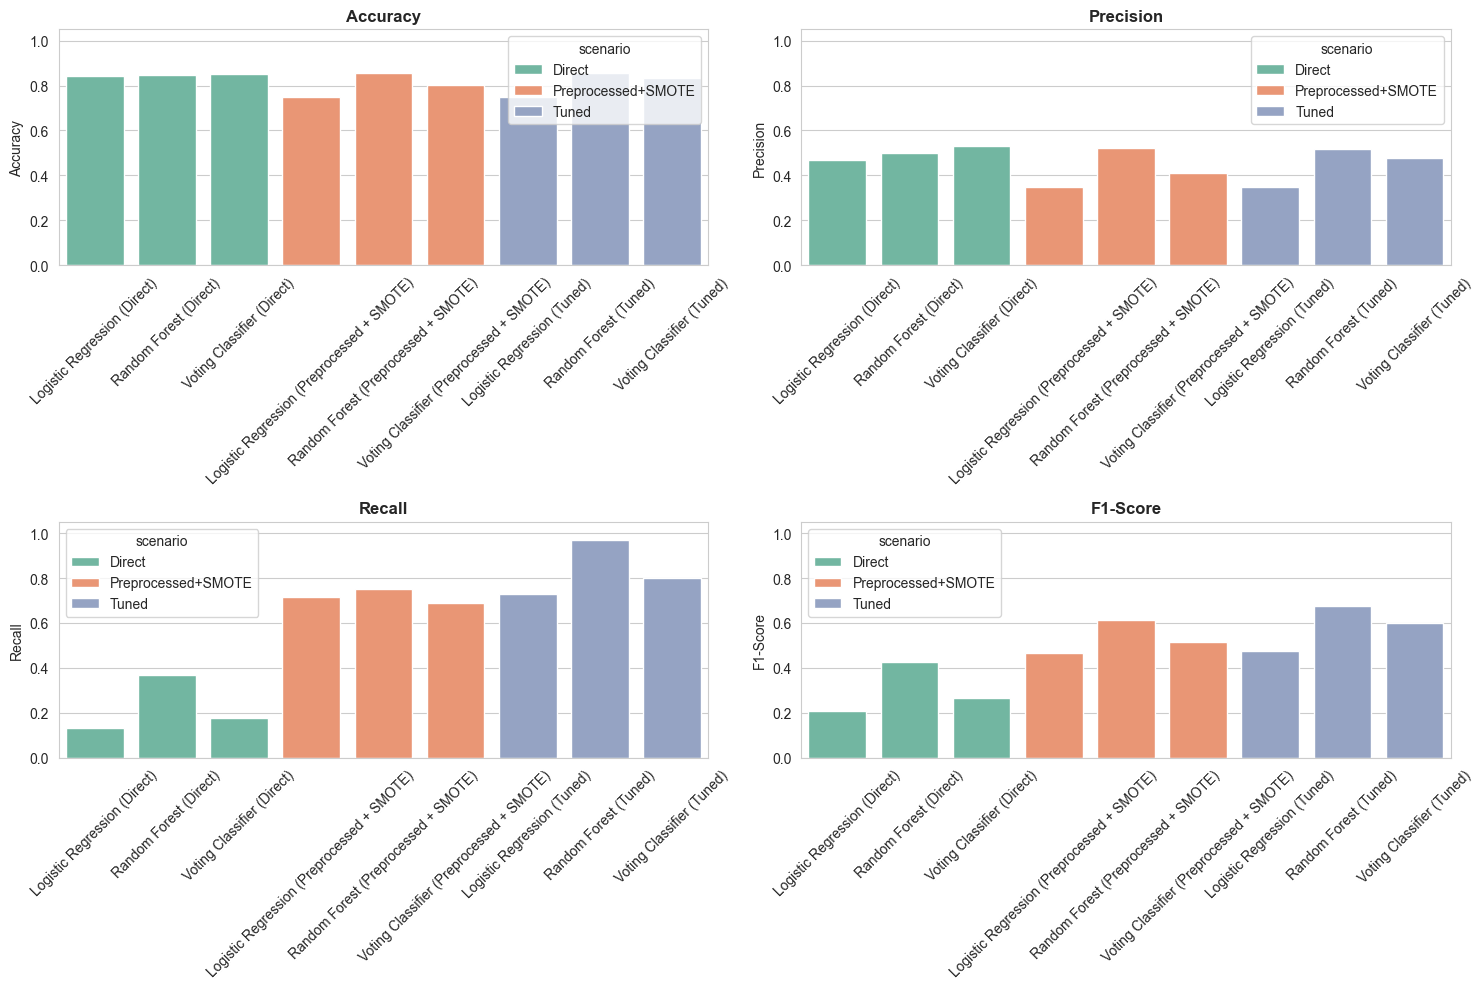

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric, title in zip(axes.flatten(),
                              ['accuracy','precision','recall','f1'],
                              ['Accuracy','Precision','Recall','F1-Score']):
    sns.barplot(data=all_results, x='model_name', y=metric, hue='scenario', ax=ax, palette='Set2')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel(title)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 5.2 Simpan Model Terbaik

In [47]:
import os

model_map = {
    'Logistic Regression (Direct)':           (lr_direct, X_train.columns.tolist(), None),
    'Random Forest (Direct)':                 (rf_direct, X_train.columns.tolist(), None),
    'Voting Classifier (Direct)':             (voting_direct, X_train.columns.tolist(), None),
    'Logistic Regression (Preprocessed + SMOTE)': (lr_pre, X_train_pre_scaled.columns.tolist(), scaler),
    'Random Forest (Preprocessed + SMOTE)':       (rf_pre, X_train_pre_scaled.columns.tolist(), scaler),
    'Voting Classifier (Preprocessed + SMOTE)':   (voting_pre, X_train_pre_scaled.columns.tolist(), scaler),
    'Logistic Regression (Tuned)':            (best_lr, selected_features, scaler),
    'Random Forest (Tuned)':                  (best_rf, selected_features, scaler),
    'Voting Classifier (Tuned)':              (best_voting, selected_features, scaler),
}

best_name = all_results.iloc[best_idx]['model_name']
best_model, best_features, best_scaler = model_map[best_name]

print(f"💾 Menyimpan model: {best_name}")
os.makedirs('model', exist_ok=True)
joblib.dump(best_model, 'model/best_model.pkl')
if best_scaler is not None:
    joblib.dump(best_scaler, 'model/scaler.pkl')
joblib.dump(best_features, 'model/feature_columns.pkl')

# Simpan juga semua kolom asli (untuk Streamlit)
joblib.dump(X_train_pre_scaled.columns.tolist(), 'model/all_columns_after_encoding.pkl')

metadata = {
    'model_name': best_name,
    'metrics': {
        'accuracy':  float(all_results.iloc[best_idx]['accuracy']),
        'precision': float(all_results.iloc[best_idx]['precision']),
        'recall':    float(all_results.iloc[best_idx]['recall']),
        'f1':        float(all_results.iloc[best_idx]['f1'])
    },
    'features': best_features,
    'requires_scaler': best_scaler is not None
}
joblib.dump(metadata, 'model/metadata.pkl')

print("✅ File yang disimpan:")
for f in os.listdir('model'):
    print(f"   - model/{f}")

💾 Menyimpan model: Random Forest (Tuned)
✅ File yang disimpan:
   - model/all_columns_after_encoding.pkl
   - model/best_model.pkl
   - model/feature_columns.pkl
   - model/metadata.pkl
   - model/scaler.pkl


## 5.3 Generate `app.py` Streamlit

In [48]:
app_code = """import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Customer Churn Prediction", page_icon="📊", layout="wide")

@st.cache_resource
def load_artifacts():
    model          = joblib.load("model/best_model.pkl")
    feature_columns = joblib.load("model/feature_columns.pkl")
    all_columns    = joblib.load("model/all_columns_after_encoding.pkl")
    metadata       = joblib.load("model/metadata.pkl")
    scaler         = joblib.load("model/scaler.pkl") if metadata.get("requires_scaler") else None
    return model, scaler, feature_columns, all_columns, metadata

model, scaler, feature_columns, all_columns, metadata = load_artifacts()

st.title("📊 Customer Churn Prediction")
st.markdown("Aplikasi prediksi churn pelanggan berbasis machine learning.")
st.markdown("---")

with st.sidebar:
    st.header("ℹ️ Info Model")
    st.write(f"**Model:** {metadata['model_name']}")
    m = metadata["metrics"]
    st.metric("Accuracy",  f"{m['accuracy']:.4f}")
    st.metric("Precision", f"{m['precision']:.4f}")
    st.metric("Recall",    f"{m['recall']:.4f}")
    st.metric("F1-Score",  f"{m['f1']:.4f}")
    st.markdown("---")
    st.caption("UAS Bengkel Koding Data Science")

st.header("📝 Input Data Pelanggan")

col1, col2 = st.columns(2)

with col1:
    satisfaction_score        = st.slider("Satisfaction Score", 0.0, 10.0, 7.0)
    total_spent               = st.number_input("Total Spent ($)", 0.0, value=500.0)
    support_tickets           = st.number_input("Support Tickets", 0, value=1)
    delivery_delay_days       = st.number_input("Delivery Delay (hari)", 0, value=0)

with col2:
    nps_score                 = st.slider("NPS Score", -100, 100, 30)
    total_visits              = st.number_input("Total Visits", 0, value=20)
    last_3_month_purchase_freq = st.number_input("Pembelian 3 Bulan Terakhir", 0, value=3)
    marketing_spend_per_user  = st.number_input("Marketing Spend per User", 0.0, value=10.0)

st.markdown("---")

if st.button("🔮 Prediksi Churn", type="primary", use_container_width=True):

    # ✅ Hanya 8 fitur terpenting — sesuai variabel input di atas
    top8 = [
        'satisfaction_score',
        'total_spent',
        'support_tickets',
        'delivery_delay_days',
        'nps_score',
        'total_visits',
        'last_3_month_purchase_freq',
        'marketing_spend_per_user',
    ]

    user_data = {
        'satisfaction_score':         satisfaction_score,
        'total_spent':                total_spent,
        'support_tickets':            support_tickets,
        'delivery_delay_days':        delivery_delay_days,
        'nps_score':                  nps_score,
        'total_visits':               total_visits,
        'last_3_month_purchase_freq': last_3_month_purchase_freq,
        'marketing_spend_per_user':   marketing_spend_per_user,
    }

    # Buat DataFrame dengan SEMUA kolom dari training (isi 0 sebagai default)
    input_df = pd.DataFrame([{col: 0 for col in all_columns}])

    # Isi hanya 8 fitur yang diinput user
    for k, v in user_data.items():
        if k in input_df.columns:
            input_df[k] = v

    input_df = input_df[all_columns]

    # Scaling (jika model membutuhkan)
    if scaler is not None:
        scaled = scaler.transform(input_df)
        scaled_df = pd.DataFrame(scaled, columns=all_columns)
    else:
        scaled_df = input_df

    # Pilih hanya fitur yang dipakai model saat training
    final_input = scaled_df[feature_columns]

    # Prediksi
    pred = model.predict(final_input)[0]
    try:
        prob = model.predict_proba(final_input)[0][1]
    except:
        prob = None

    st.markdown("## 📊 Hasil Prediksi")
    if pred == 1:
        st.error("⚠️ **Pelanggan diprediksi CHURN**")
        if prob is not None:
            st.write(f"Probabilitas churn: **{prob*100:.2f}%**")
        st.warning("💡 Rekomendasi: Lakukan retention campaign — diskon, hubungi customer service.")
    else:
        st.success("✅ **Pelanggan diprediksi TIDAK CHURN**")
        if prob is not None:
            st.write(f"Probabilitas churn: **{prob*100:.2f}%**")
        st.info("💡 Pelanggan stabil. Pertahankan kualitas layanan.")

    if prob is not None:
        st.progress(float(prob))

st.markdown("---")
st.caption("Built with ❤️ using Streamlit | UAS Bengkel Koding 2025/2026")
"""

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print("✅ app.py berhasil dibuat")

✅ app.py berhasil dibuat


## 5.4 Generate `requirements.txt`

In [49]:
requirements = """streamlit
pandas
numpy
scikit-learn
imbalanced-learn
joblib
matplotlib
seaborn
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)
print("✅ requirements.txt berhasil dibuat")
print(requirements)

✅ requirements.txt berhasil dibuat
streamlit
pandas
numpy
scikit-learn
imbalanced-learn
joblib
matplotlib
seaborn



## 5.5 Generate `README.md`

In [50]:
readme = """# 🎓 UAS Bengkel Koding — Customer Churn Prediction

Project UAS Mata Kuliah Bengkel Koding Data Science — UDINUS.

## 📌 Fitur
- EDA komprehensif dengan analisis class imbalance
- 9 model (3 kategori × 3 skenario)
- Imbalance handling dengan **SMOTE**
- Hyperparameter tuning (GridSearchCV & RandomizedSearchCV)
- Aplikasi web Streamlit untuk prediksi real-time

## 🗂️ Struktur Project
```
.
├── UAS_Bengkod_Churn_Prediction.ipynb
├── app.py
├── requirements.txt
├── model/
│   ├── best_model.pkl
│   ├── scaler.pkl
│   ├── feature_columns.pkl
│   ├── all_columns_after_encoding.pkl
│   └── metadata.pkl
└── README.md
```

## 🚀 Menjalankan Lokal
```bash
pip install -r requirements.txt
streamlit run app.py
```

## 🌐 Demo
[Streamlit App URL]

## 👤 Author
- Nama : Firnanda Rahmawati
- NIM: A11.2023.15373
"""
with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)
print("✅ README.md berhasil dibuat")

✅ README.md berhasil dibuat
